In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
from pathlib import Path
import matplotlib.pyplot as plt


home = os.environ.get("HOME")
if not home:
    raise RuntimeError("HOME env not set.")
input_dir = Path(home) / "Projects/Masterarbeit/simdata"
input_file_path = input_dir / "grid_search_data.jsonl"

jsonObj = pd.read_json(path_or_buf= input_file_path, lines=True)

print(len(jsonObj))


630


In [19]:
jsonObj

,angle,glenohumeral_roll_joint,glenohumeral_yaw_joint,sternoclavicular_pitch_joint,sternoclavicular_yaw_joint,turn
0,115.204076,0.50,0.50,0.10,0.10,0
1,115.226635,0.50,0.50,0.35,0.10,1
2,115.249227,0.50,0.50,0.60,0.10,2
3,115.273805,0.50,0.50,0.85,0.10,3
4,115.296531,0.50,0.50,1.10,0.10,4
...,...,...,...,...,...,...
625,117.467434,1.50,1.50,1.10,1.10,624
626,116.340315,1.25,0.75,0.10,0.60,210
627,117.390835,1.25,1.25,0.60,1.10,472
628,116.137904,0.75,1.50,0.10,0.35,530


In [20]:
jsonObj["turn"].nunique()


625

In [21]:
counts =jsonObj["turn"].value_counts()
jsonObj[jsonObj["turn"].duplicated(keep=False)].sort_values("turn")

,angle,glenohumeral_roll_joint,glenohumeral_yaw_joint,sternoclavicular_pitch_joint,sternoclavicular_yaw_joint,turn
0,115.204076,0.5,0.5,0.10,0.1,0
5,115.212058,0.5,0.5,0.10,0.1,0
1,115.226635,0.5,0.5,0.35,0.1,1
6,115.234604,0.5,0.5,0.35,0.1,1
2,115.249227,0.5,0.5,0.60,0.1,2
7,115.257212,0.5,0.5,0.60,0.1,2
3,115.273805,0.5,0.5,0.85,0.1,3
8,115.279801,0.5,0.5,0.85,0.1,3
4,115.296531,0.5,0.5,1.10,0.1,4
9,115.302316,0.5,0.5,1.10,0.1,4


In [22]:
missing = pd.Index(range(625)).difference(jsonObj["turn"])
missing

Index([], dtype='int64')

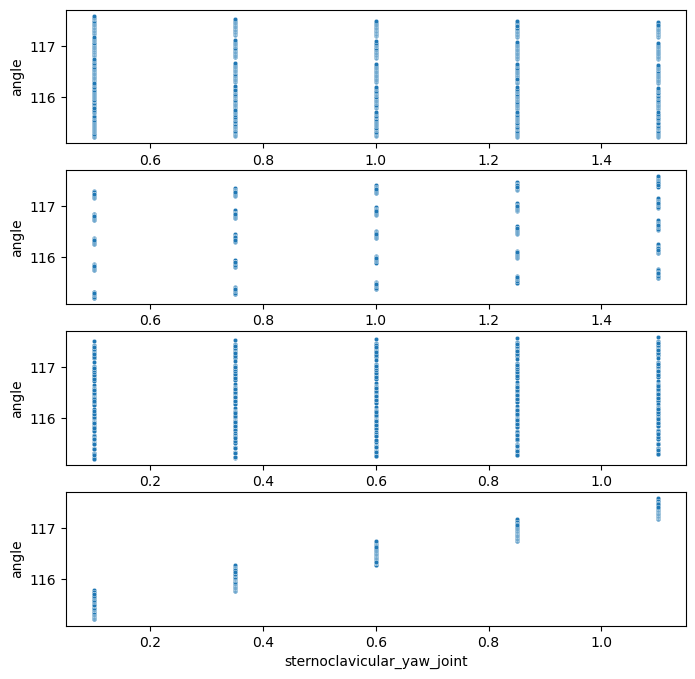

In [28]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(8,8))
sns.scatterplot(jsonObj, x="glenohumeral_roll_joint", y="angle", ax=ax1, s=10)
sns.scatterplot(jsonObj, x="glenohumeral_yaw_joint", y="angle", ax=ax2, s=10)
sns.scatterplot(jsonObj, x="sternoclavicular_pitch_joint", y="angle", ax=ax3, s=10)
sns.scatterplot(jsonObj, x="sternoclavicular_yaw_joint", y="angle", ax=ax4, s=10)
plt.show()



In [65]:
# p1= "glenohumeral_roll_joint"
# p2= "glenohumeral_yaw_joint"
# p3= "sternoclavicular_pitch_joint"
# p4= "sternoclavicular_yaw_joint"

# jsonObj = jsonObj.iloc[5:].reset_index(drop=True)


# for (p3, p4), sub in jsonObj.groupby([p3, p4]):
#     pivot = sub.pivot(index=p2, columns=p1, values="angle")
    
#     plt.figure()
#     sns.heatmap(pivot, annot=False, cmap="viridis")
#     plt.title(f"p3={p3}, p4={p4}")
#     plt.xlabel(p1)
#     plt.ylabel(p2)
#     plt.show()

In [29]:
best = jsonObj.loc[jsonObj["angle"].idxmin()]
print(best)

angle                           115.204076
glenohumeral_roll_joint           0.500000
glenohumeral_yaw_joint            0.500000
sternoclavicular_pitch_joint      0.100000
sternoclavicular_yaw_joint        0.100000
turn                              0.000000
Name: 0, dtype: float64


In [31]:
top = jsonObj.nsmallest(20, "angle")
print(top)

          angle  glenohumeral_roll_joint  glenohumeral_yaw_joint  \
0    115.204076                     0.50                     0.5   
105  115.209738                     1.50                     0.5   
80   115.210092                     1.25                     0.5   
5    115.212058                     0.50                     0.5   
55   115.224534                     1.00                     0.5   
30   115.225568                     0.75                     0.5   
1    115.226635                     0.50                     0.5   
106  115.232814                     1.50                     0.5   
81   115.233440                     1.25                     0.5   
6    115.234604                     0.50                     0.5   
56   115.247591                     1.00                     0.5   
31   115.248290                     0.75                     0.5   
2    115.249227                     0.50                     0.5   
107  115.256069                     1.50        

<AxesSubplot: xlabel='glenohumeral_roll_joint', ylabel='sternoclavicular_pitch_joint'>

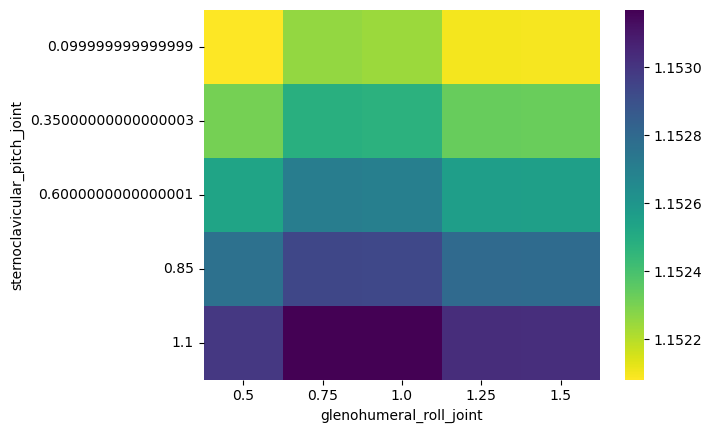

In [32]:
reduced = jsonObj[
    np.isclose(jsonObj["glenohumeral_yaw_joint"], 0.5) &
    np.isclose(jsonObj["sternoclavicular_yaw_joint"], 0.1)
]
reduced = reduced.copy()
reduced["angle"] = reduced["angle"] / 100
pivot = reduced.pivot_table(
    index="sternoclavicular_pitch_joint",
    columns="glenohumeral_roll_joint",
    values="angle",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="viridis_r")